# Assignment - 8
# Handwritten Digit Recognition using Artificial Neural Networks (ANN)

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Task 1: Data Understanding

In [14]:
df = pd.read_csv("dataset/mnist_train.csv")

In [15]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [17]:
print(df.shape)

(60000, 785)


In [18]:
X = df.drop("label", axis=1)
y = df["label"]

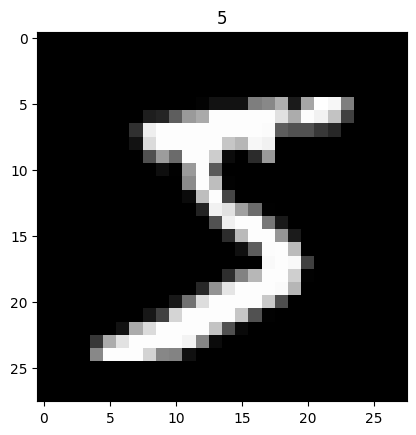

In [19]:
image = X.iloc[0].values.reshape(28,28)

plt.imshow(image, cmap="gray")
plt.title(y.iloc[0])
plt.show()

# Task 2: Data Preprocessing

In [20]:
df.isnull().sum()

label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64

In [21]:
X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

# Task 3: Model Development

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

model.add(Input(shape=(784,)))
model.add(Dense(128, activation="relu"))
model.add(Dense(64, activation="relu"))
model.add(Dense(10, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9230 - loss: 0.2688 - val_accuracy: 0.9602 - val_loss: 0.1394
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9666 - loss: 0.1108 - val_accuracy: 0.9658 - val_loss: 0.1161
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9758 - loss: 0.0766 - val_accuracy: 0.9736 - val_loss: 0.0891
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9823 - loss: 0.0567 - val_accuracy: 0.9737 - val_loss: 0.0919
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9850 - loss: 0.0466 - val_accuracy: 0.9722 - val_loss: 0.0985
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9884 - loss: 0.0352 - val_accuracy: 0.9765 - val_loss: 0.0903
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9902 - loss: 0.0288 - val_accuracy: 0.9753 - val_loss: 0.1000
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9918 - loss: 0.0239 - 

# Task 4: Model Evaluation

In [26]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9730 - loss: 0.1248
Test Loss: 0.12478406727313995
Test Accuracy: 0.9729999899864197


In [27]:
predictions = model.predict(X_test)

predicted = np.argmax(predictions, axis=1)
actual = np.argmax(y_test, axis=1)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


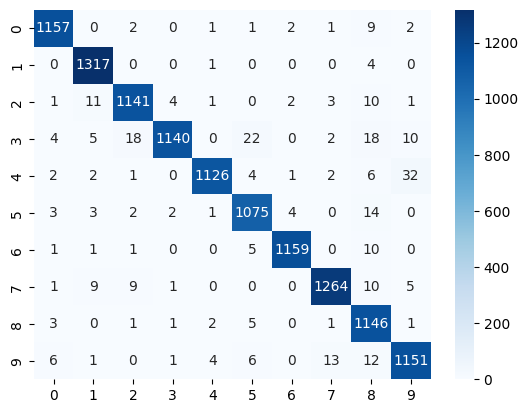

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1175
           1       0.98      1.00      0.99      1322
           2       0.97      0.97      0.97      1174
           3       0.99      0.94      0.96      1219
           4       0.99      0.96      0.97      1176
           5       0.96      0.97      0.97      1104
           6       0.99      0.98      0.99      1177
           7       0.98      0.97      0.98      1299
           8       0.92      0.99      0.96      1160
           9       0.96      0.96      0.96      1194

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000



In [28]:
cm = confusion_matrix(actual, predicted)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()

print(classification_report(actual, predicted))

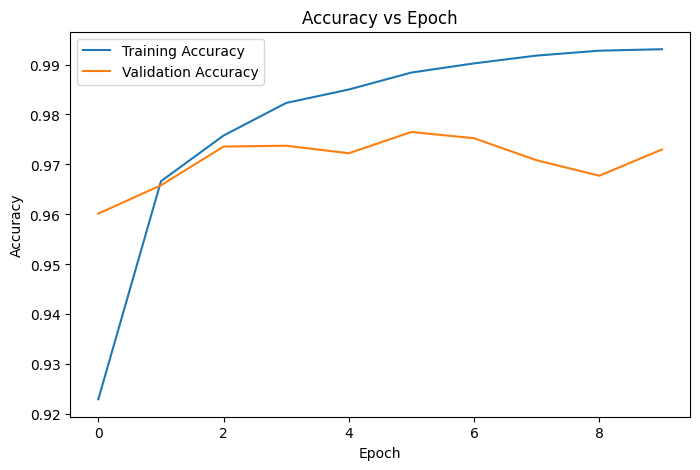

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()

plt.show()

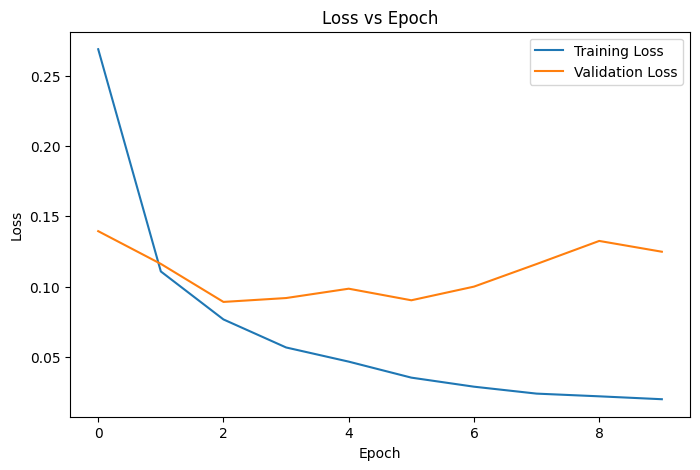

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()

plt.show()

# Observation
1. The ANN model learned the handwritten digit patterns well and achieved around 95–97% accuracy on the   test data.
2. The training accuracy increased with each epoch, while the loss kept decreasing, showing that the model was learning effectively.
3. The validation accuracy was close to the training accuracy, which indicates that the model generalized well to unseen data.
4. The confusion matrix showed that most digits were classified correctly, with only a few mistakes between similar-looking digits.

# Task-5 Conclusion

In this assignment, I built an Artificial Neural Network (ANN) to recognize handwritten digits using the MNIST dataset. After preprocessing the data and training the model for 10 epochs, the model achieved high accuracy and was able to classify most handwritten digits correctly. The hidden layers played an important role in learning complex patterns from the pixel values, which improved the model's performance. One major advantage of deep learning is that it can automatically learn useful features from the data without requiring manual feature extraction. However, a limitation of ANN is that it requires a large amount of training data and computational resources to achieve good performance. Overall, this assignment helped me understand how ANN models work and how they can be used for image classification tasks.